# 🛡️ QoS Sentry — LSTM QoE Forecasting (v3 — Overfitting Fixed)

**Project:** QoS Sentry — AI-powered SDN Telemetry Monitoring  
**Model:** Unidirectional LSTM with transition-aware training  
**Objective:** Predict future QoE class at **t+1, t+3, t+5** before SLA breach occurs

---

## 🔴 Problems Fixed in v3 (vs v2)

| Problem | Evidence | Fix Applied |
|---|---|---|
| Same hyperparams for all horizons | t+5 underfitting, t+3 overfitting fast | Per-horizon CFG (Fix A) |
| minority_boost=2.0 at long horizons | CAPACITY_EXHAUSTED precision=0.16 at t+5 | Reduce boost per horizon (Fix B) |
| t+5 model capacity too small | Train F1 still rising at early stop | hidden=128, layers=3 for t+5 (Fix C) |
| Gradient instability at t+5 | Noisy val loss curve | clip_grad_norm 1.0→0.5 (Fix D) |
| CrossEntropyLoss causes over-firing | Precision collapse on minority classes | Focal Loss (Fix E) |
| patience=8 for all horizons | t+3 stopped too late, t+5 too early | Per-horizon patience (Fix F) |
| CosineAnnealing never completed cycle | T_0=20 but stop at ep 9-13 | ReduceLROnPlateau per horizon (Fix G) |
| transition_oversample=10 same for all | Too high for t+3/t+5 (hard task) | Reduce per horizon (Fix H) |

## 1. Imports & Configuration

In [82]:
import os, json, joblib, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
os.makedirs('artifacts', exist_ok=True)

# ── Shared config (horizon-independent) ──────────────────────────────────────
CFG = dict(
    # Data
    window_size   = 60,
    horizons      = [1, 3, 5],
    train_frac    = 0.70,
    val_frac      = 0.15,

    # Feature engineering
    roll_window   = 10,
    lag_steps     = [1, 3, 5],

    # Shared training defaults
    batch_size      = 128,
    max_epochs      = 100,
    label_smoothing = 0.0,
    weight_decay    = 1e-3,

    # Class weighting
    minority_boost_classes = ['CALL_DROP', 'CAPACITY_EXHAUSTED'],
)

# ── v4: Per-horizon configs ───────────────────────────────────────────────────
# t+1: focal_gamma lowered (NORMAL→LOW_THROUGHPUT confusion), boost reduced
# t+3: lr reduced (best at ep=1 means LR overshoots), smaller model, less boost
# t+5: lr reduced (train loss → 0.01), more dropout, more boost (recall=0.60)
HORIZON_CFG = {
    1: dict(                       # ← DO NOT CHANGE, working perfectly
        lr                    = 1e-4,
        hidden_size           = 64,
        num_layers            = 2,
        dropout               = 0.4,
        patience              = 8,
        transition_oversample = 10,
        minority_boost        = 1.5,
        focal_gamma           = 0.5,
        clip_grad             = 0.5,
    ),
    3: dict(
        lr                    = 1e-4,  # was 5e-5 — too slow, raise back up
        hidden_size           = 64,
        num_layers            = 2,
        dropout               = 0.5,   # was 0.6 — slightly less, model underfitting
        patience              = 8,     # was 5 — give more time at proper LR
        transition_oversample = 8,
        minority_boost        = 1.2,
        focal_gamma           = 1.0,   # was 2.0 — NORMAL confusion, reduce focal pressure
        clip_grad             = 0.5,
    ),
    5: dict(
        lr                    = 7e-5,  # was 1e-4 — slightly lower, best at ep=1 means LR slightly high
        hidden_size           = 128,
        num_layers            = 3,
        dropout               = 0.45,  # was 0.4 — slightly more regularisation
        patience              = 12,
        transition_oversample = 6,
        minority_boost        = 1.1,   # was 1.3 — precision=0.44 still too low, reduce boost
        focal_gamma           = 1.5,
        clip_grad             = 0.5,
        weight_decay          = 3e-3,
    ),
}

with open('artifacts/config.json', 'w') as f:
    json.dump(
        {**CFG, 'horizon_cfg': {str(k): v for k, v in HORIZON_CFG.items()}},
        f, indent=2
    )
print('Config saved.')
print('\nPer-horizon configs:')
for h, hc in HORIZON_CFG.items():
    print(f'  t+{h}: lr={hc["lr"]}, hidden={hc["hidden_size"]}, '
          f'layers={hc["num_layers"]}, dropout={hc["dropout"]}, '
          f'patience={hc["patience"]}, boost={hc["minority_boost"]}, '
          f'gamma={hc["focal_gamma"]}')

Device: cuda
Config saved.

Per-horizon configs:
  t+1: lr=0.0001, hidden=64, layers=2, dropout=0.4, patience=8, boost=1.5, gamma=0.5
  t+3: lr=0.0001, hidden=64, layers=2, dropout=0.5, patience=8, boost=1.2, gamma=1.0
  t+5: lr=7e-05, hidden=128, layers=3, dropout=0.45, patience=12, boost=1.1, gamma=1.5


## 2. Data Exploration

In [83]:
LOCAL_PATH = 'network_qoe_latest.csv'
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PATH = '/content/drive/MyDrive/network_qoe_latestin.csv'
except Exception:
    PATH = LOCAL_PATH

df_raw = pd.read_csv(PATH)
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'], unit='s')
print(f'Shape: {df_raw.shape}')
df_raw.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (93276, 30)


,run_id,timestamp,datetime,segment,switch_id,port_no,mos_voice,e2e_delay_ms,plr,jitter_ms,...,dns_latency_ms,availability,rx_bytes,tx_bytes,rx_packets,tx_packets,ctrl_plane_rtt_ms,flow_count,mos_source,label
0,run_20260325_115425,2026-03-25 10:45:53.272696018,11:45:53,INTERNET,1,4,4.398,10.942,0.0,1.2151,...,0.0,1.0,0,98,0,1,10.942,0,ctrl_plane_fallback,NORMAL
1,run_20260325_115425,2026-03-25 10:45:53.272696018,11:45:53,OUTDOOR_RAN,1,1,4.398,10.942,0.0,1.2151,...,0.0,1.0,98,98,1,1,10.942,0,ctrl_plane_fallback,NORMAL
2,run_20260325_115425,2026-03-25 10:45:53.272696018,11:45:53,INDOOR_RAN,1,2,4.398,10.942,0.0,1.2151,...,0.0,1.0,0,98,0,1,10.942,0,ctrl_plane_fallback,NORMAL


=== QoE Label Distribution ===
                    count      %
label                           
NORMAL              29028  31.12
LOW_THROUGHPUT      22844  24.49
POOR_VOICE_QUALITY  15804  16.94
HIGH_LATENCY        13840  14.84
CALL_DROP            7756   8.32
CAPACITY_EXHAUSTED   4004   4.29

Imbalance ratio: 7.2x


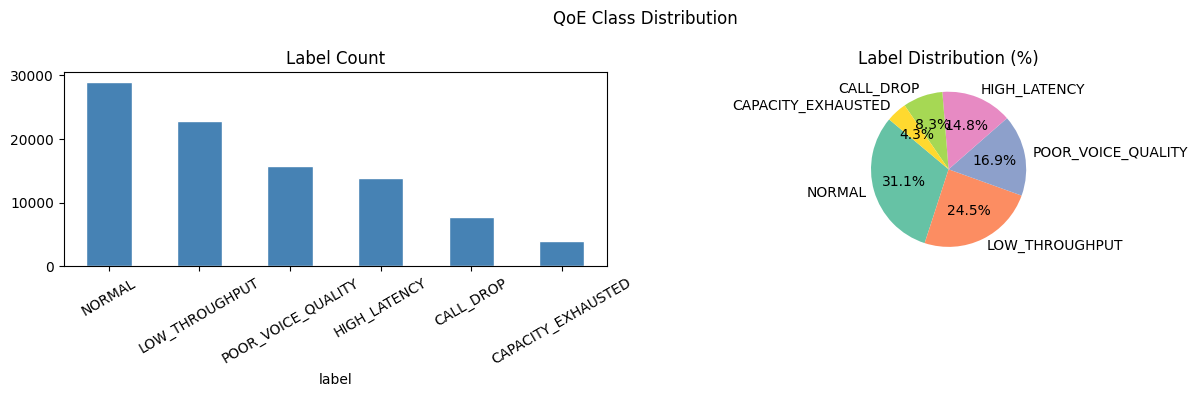

In [84]:
# ── Label distribution ────────────────────────────────────────────────────────
label_counts = df_raw['label'].value_counts()
label_pct    = label_counts / len(df_raw) * 100
print('=== QoE Label Distribution ===')
print(pd.DataFrame({'count': label_counts, '%': label_pct.round(2)}).to_string())
print(f'\nImbalance ratio: {label_counts.max()/label_counts.min():.1f}x')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
label_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Label Count'); axes[0].tick_params(axis='x', rotation=30)
axes[1].pie(label_counts, labels=label_counts.index, autopct='%1.1f%%',
            startangle=140, colors=plt.cm.Set2.colors)
axes[1].set_title('Label Distribution (%)')
plt.suptitle('QoE Class Distribution', fontsize=12)
plt.tight_layout()
plt.savefig('artifacts/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [85]:
# ── Segment analysis ─────────────────────────────────────────────────────────
print('=== Segment Overview ===')
for seg in df_raw['segment'].unique():
    sub = df_raw[df_raw['segment']==seg].sort_values('timestamp')
    dts = sub['timestamp'].diff().dropna().dt.total_seconds()
    print(f'  {seg:15s}: {len(sub):,} rows | Δt={dts.median():.2f}s | '
          f'e2e_delay_mean={sub["e2e_delay_ms"].mean():.1f}ms | '
          f'throughput_mean={sub["throughput_mbps"].mean():.3f}Mbps')

print()
print('✅ Labels are IDENTICAL across segments (same simulation run).')
print('   But FEATURES differ significantly per segment (different network paths).')
print('   → Using all 4 segments gives 4× more training data with feature diversity.')

=== Segment Overview ===
  INTERNET       : 23,319 rows | Δt=2.06s | e2e_delay_mean=7.7ms | throughput_mean=0.203Mbps
  OUTDOOR_RAN    : 23,319 rows | Δt=2.06s | e2e_delay_mean=29.7ms | throughput_mean=0.164Mbps
  INDOOR_RAN     : 23,319 rows | Δt=2.06s | e2e_delay_mean=49.6ms | throughput_mean=0.056Mbps
  IMS_CDN        : 23,319 rows | Δt=2.06s | e2e_delay_mean=29.8ms | throughput_mean=0.209Mbps

✅ Labels are IDENTICAL across segments (same simulation run).
   But FEATURES differ significantly per segment (different network paths).
   → Using all 4 segments gives 4× more training data with feature diversity.


In [86]:
# ── State run-length analysis ────────────────────────────────────────────────
seg_ref = df_raw[df_raw['segment']=='INTERNET'].sort_values('timestamp')
labels  = seg_ref['label'].values

runs = []
curr, count = labels[0], 1
for l in labels[1:]:
    if l == curr:
        count += 1
    else:
        runs.append((curr, count))
        curr, count = l, 1
runs.append((curr, count))
run_df = pd.DataFrame(runs, columns=['label','length'])

print('=== State Run-Length Analysis ===')
print(run_df.groupby('label')['length'].describe().round(1))
print(f'\nWindow size = {CFG["window_size"]} steps')
print(f'Average state run = {run_df["length"].mean():.0f} steps')

transitions = sum(1 for i in range(1, len(labels)) if labels[i] != labels[i-1])
print(f'\n   State transitions: {transitions} out of {len(labels)} rows ({transitions/len(labels)*100:.1f}%)')

=== State Run-Length Analysis ===
                    count   mean   std   min    25%    50%    75%    max
label                                                                   
CALL_DROP            23.0   84.3  16.5  57.0   68.5   86.0   95.5  109.0
CAPACITY_EXHAUSTED   11.0   91.0  15.6  65.0   81.0   95.0  101.0  112.0
HIGH_LATENCY         30.0  115.3  17.0  86.0  102.2  115.0  129.0  140.0
LOW_THROUGHPUT       50.0  114.2  18.6  65.0  100.5  111.0  132.8  143.0
NORMAL              149.0   48.7  65.0   2.0    5.0    5.0   86.0  326.0
POOR_VOICE_QUALITY   35.0  112.9  16.0  87.0  101.0  111.0  127.5  144.0

Window size = 60 steps
Average state run = 78 steps

   State transitions: 297 out of 23319 rows (1.3%)


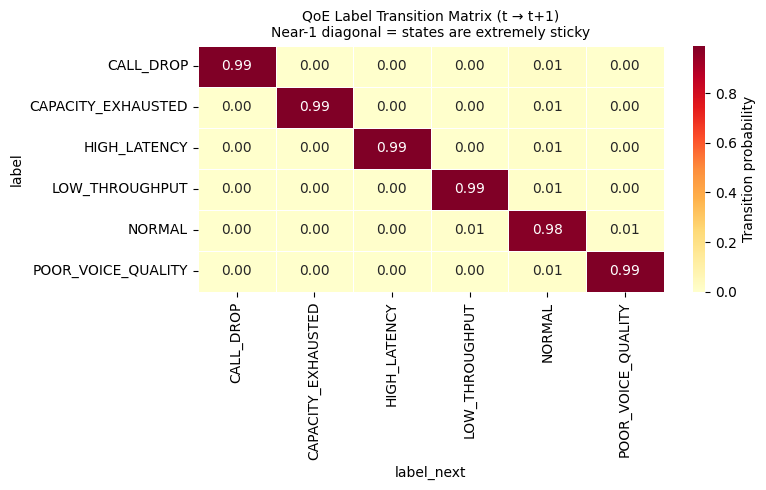

Self-transition probabilities:
  P(CALL_DROP → CALL_DROP) = 0.9880
  P(CAPACITY_EXHAUSTED → CAPACITY_EXHAUSTED) = 0.9890
  P(HIGH_LATENCY → HIGH_LATENCY) = 0.9910
  P(LOW_THROUGHPUT → LOW_THROUGHPUT) = 0.9910
  P(NORMAL → NORMAL) = 0.9790
  P(POOR_VOICE_QUALITY → POOR_VOICE_QUALITY) = 0.9910


In [87]:
# ── Label transition matrix ───────────────────────────────────────────────────
seg_df = seg_ref.copy()
seg_df['label_next'] = seg_df['label'].shift(-1)
trans = seg_df.groupby(['label','label_next']).size().unstack(fill_value=0)
trans_prob = trans.div(trans.sum(axis=1), axis=0).round(3)

plt.figure(figsize=(8, 5))
sns.heatmap(trans_prob, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Transition probability'})
plt.title('QoE Label Transition Matrix (t → t+1)\n'
          'Near-1 diagonal = states are extremely sticky', fontsize=10)
plt.tight_layout()
plt.savefig('artifacts/transition_matrix.png', dpi=150)
plt.show()

print('Self-transition probabilities:')
for cls in trans_prob.index:
    if cls in trans_prob.columns:
        print(f'  P({cls} → {cls}) = {trans_prob.loc[cls, cls]:.4f}')

## 3. Preprocessing & Feature Engineering

In [88]:
DROP_COLS = [
    'run_id', 'datetime', 'mos_source', 'switch_id',
    'rebuffering_count', 'total_stall_seconds', 'rx_dropped', 'tx_dropped',
]

SLA_FEATURES = [
    'e2e_delay_ms', 'jitter_ms', 'plr', 'throughput_mbps',
    'mos_voice', 'ctrl_plane_rtt_ms', 'availability',
]
LAG_COLS  = ['e2e_delay_ms', 'throughput_mbps', 'mos_voice', 'plr']
DIFF_COLS = ['e2e_delay_ms', 'throughput_mbps', 'plr']


def preprocess_segment(seg_df, train_frac, roll_w, lag_steps,
                        le=None, scaler=None, fit=True):
    df = seg_df.copy().sort_values('timestamp').reset_index(drop=True)

    df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)

    if 'video_start_time_ms' in df.columns:
        df['video_start_time_ms'] = df['video_start_time_ms'].clip(0, 1e8)

    if 'flow_count' in df.columns:
        df['flow_count'] = df['flow_count'].replace(0, np.nan).ffill().bfill().fillna(0)

    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)

    NUMERIC = [c for c in df.select_dtypes(include=np.number).columns
               if c not in ['port_no']]
    train_end_iqr = int(train_frac * len(df))
    Q1  = df[NUMERIC].iloc[:train_end_iqr].quantile(0.25)
    Q3  = df[NUMERIC].iloc[:train_end_iqr].quantile(0.75)
    IQR = Q3 - Q1
    df[NUMERIC] = df[NUMERIC].clip(
        lower=pd.Series((Q1 - 3*IQR).to_dict()),
        upper=pd.Series((Q3 + 3*IQR).to_dict()), axis=1
    )

    df[NUMERIC] = df[NUMERIC].interpolate(method='linear').ffill().bfill()

    if fit:
        le = LabelEncoder().fit(df['label'])
    y_all = le.transform(df['label']).astype(np.int64)

    df['label_encoded'] = y_all.astype(np.float32)

    if 'segment' in df.columns:
        df = pd.get_dummies(df, columns=['segment'], drop_first=False)

    W = roll_w
    for col in SLA_FEATURES:
        if col in df.columns:
            df[f'{col}_rmean'] = df[col].rolling(W, min_periods=1).mean()
            df[f'{col}_rstd']  = df[col].rolling(W, min_periods=1).std().fillna(0)
            df[f'{col}_rmax']  = df[col].rolling(W, min_periods=1).max()

    df['label_enc_rmean'] = df['label_encoded'].rolling(W, min_periods=1).mean()
    df['label_enc_rstd']  = df['label_encoded'].rolling(W, min_periods=1).std().fillna(0)

    for col in LAG_COLS:
        for lag in lag_steps:
            if col in df.columns:
                df[f'{col}_lag{lag}'] = df[col].shift(lag).bfill()

    for lag in lag_steps:
        df[f'label_lag{lag}'] = df['label_encoded'].shift(lag).bfill()

    for col in DIFF_COLS:
        if col in df.columns:
            df[f'{col}_diff'] = df[col].diff().fillna(0)

    if all(c in df.columns for c in ['mos_voice', 'plr', 'jitter_ms']):
        df['voice_pressure'] = (
            (5 - df['mos_voice'].clip(1, 5)) / 4 +
            df['plr'].clip(0, 1) +
            df['jitter_ms'].clip(0, 200) / 200
        ) / 3

    if all(c in df.columns for c in ['throughput_mbps', 'effective_bitrate_mbps']):
        df['throughput_gap'] = df['effective_bitrate_mbps'] - df['throughput_mbps']

    if all(c in df.columns for c in ['buffering_ratio', 'rebuffering_freq']):
        df['stream_stress'] = df['buffering_ratio'] * (df['rebuffering_freq'] + 1)

    if 'flow_count' in df.columns:
        df['flow_pressure'] = np.log1p(df['flow_count'])

    df['hour']     = df['timestamp'].dt.hour
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df.drop(columns=['hour'], inplace=True)

    EXCLUDE   = ['timestamp', 'label']
    feat_cols = [c for c in df.columns if c not in EXCLUDE]
    X_df      = df[feat_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
    X_all     = X_df.values.astype(np.float32)

    train_end = int(train_frac * len(X_all))
    scaler = RobustScaler().fit(X_all[:train_end])
    X_scaled = scaler.transform(X_all)

    return X_scaled, y_all, le, scaler, feat_cols


print('preprocess_segment() defined.')

preprocess_segment() defined.


In [89]:
# ── Process ALL 4 segments ────────────────────────────────────────────────────
SEGMENTS = df_raw['segment'].unique().tolist()
print(f'Processing {len(SEGMENTS)} segments: {SEGMENTS}')

ref_seg = df_raw[df_raw['segment'] == 'INTERNET'].copy()
_, _, label_encoder, _, _ = preprocess_segment(
    ref_seg, CFG['train_frac'], CFG['roll_window'], CFG['lag_steps'], fit=True
)

seg_data = {}
for seg_name in SEGMENTS:
    seg_df = df_raw[df_raw['segment'] == seg_name].copy()
    X_sc, y, le, sc, fc = preprocess_segment(
        seg_df, CFG['train_frac'], CFG['roll_window'], CFG['lag_steps'],
        le=label_encoder, fit=False
    )
    seg_data[seg_name] = (X_sc, y, fc)
    print(f'  {seg_name}: X={X_sc.shape}, y={y.shape}')

NUM_CLASSES = len(label_encoder.classes_)
INPUT_SIZE  = seg_data[SEGMENTS[0]][0].shape[1]
feat_cols   = seg_data[SEGMENTS[0]][2]

joblib.dump(label_encoder, 'artifacts/label_encoder.pkl')
with open('artifacts/feature_columns.json', 'w') as f:
    json.dump(feat_cols, f, indent=2)

print(f'\nClasses ({NUM_CLASSES}): {label_encoder.classes_}')
print(f'Input size: {INPUT_SIZE} features')

Processing 4 segments: ['INTERNET', 'OUTDOOR_RAN', 'INDOOR_RAN', 'IMS_CDN']
  INTERNET: X=(23319, 70), y=(23319,)
  OUTDOOR_RAN: X=(23319, 70), y=(23319,)
  INDOOR_RAN: X=(23319, 70), y=(23319,)
  IMS_CDN: X=(23319, 70), y=(23319,)

Classes (6): ['CALL_DROP' 'CAPACITY_EXHAUSTED' 'HIGH_LATENCY' 'LOW_THROUGHPUT' 'NORMAL'
 'POOR_VOICE_QUALITY']
Input size: 70 features


In [90]:
# ── Sequence creation & time-aware split ─────────────────────────────────────

def create_sequences(X, y, window, horizon):
    Xs, ys, is_transition = [], [], []
    max_i = len(X) - window - horizon + 1
    for i in range(max_i):
        target      = y[i + window + horizon - 1]
        last_in_win = y[i + window - 1]
        Xs.append(X[i : i + window])
        ys.append(target)
        is_transition.append(target != last_in_win)
    return (
        np.array(Xs, dtype=np.float32),
        np.array(ys, dtype=np.int64),
        np.array(is_transition, dtype=bool)
    )


def time_split(X, y, mask, train_frac, val_frac):
    N = len(X)
    t = int(train_frac * N)
    v = t + int(val_frac * N)
    return (
        X[:t],  y[:t],  mask[:t],
        X[t:v], y[t:v], mask[t:v],
        X[v:],  y[v:],  mask[v:],
    )


datasets = {}
for h in CFG['horizons']:
    all_Xtr, all_ytr, all_mtr = [], [], []
    all_Xva, all_yva          = [], []
    all_Xte, all_yte          = [], []

    for seg_name, (X_sc, y, _) in seg_data.items():
        Xs, ys, masks = create_sequences(X_sc, y, CFG['window_size'], h)
        Xtr, ytr, mtr, Xva, yva, mva, Xte, yte, _ = time_split(
            Xs, ys, masks, CFG['train_frac'], CFG['val_frac']
        )
        all_Xtr.append(Xtr); all_ytr.append(ytr); all_mtr.append(mtr)
        all_Xva.append(Xva); all_yva.append(yva)
        all_Xte.append(Xte); all_yte.append(yte)

    datasets[h] = dict(
        X_train    = np.concatenate(all_Xtr),
        y_train    = np.concatenate(all_ytr),
        mask_train = np.concatenate(all_mtr),
        X_val      = np.concatenate(all_Xva),
        y_val      = np.concatenate(all_yva),
        X_test     = np.concatenate(all_Xte),
        y_test     = np.concatenate(all_yte),
    )
    d = datasets[h]
    n_trans = d['mask_train'].sum()
    n_total = len(d['y_train'])
    print(f'h=t+{h} → train={d["X_train"].shape} | '
          f'transition seqs={n_trans} ({n_trans/n_total*100:.1f}%) | '
          f'val={d["X_val"].shape} | test={d["X_test"].shape}')

h=t+1 → train=(65124, 60, 70) | transition seqs=836 (1.3%) | val=(13952, 60, 70) | test=(13960, 60, 70)
h=t+3 → train=(65116, 60, 70) | transition seqs=2500 (3.8%) | val=(13952, 60, 70) | test=(13960, 60, 70)
h=t+5 → train=(65112, 60, 70) | transition seqs=4028 (6.2%) | val=(13952, 60, 70) | test=(13956, 60, 70)


## 4. DataLoader & Loss Function

In [91]:
# ── FIX H: Per-horizon transition oversampling via make_loader ────────────────
def make_loader(X, y, mask=None, shuffle=False,
                oversample_transitions=False, oversample_factor=10):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y))
    if oversample_transitions and mask is not None:
        weights = np.where(mask, float(oversample_factor), 1.0)
        sampler = WeightedRandomSampler(
            weights     = torch.tensor(weights, dtype=torch.float32),
            num_samples = len(weights),
            replacement = True
        )
        return DataLoader(ds, batch_size=CFG['batch_size'], sampler=sampler)
    return DataLoader(ds, batch_size=CFG['batch_size'], shuffle=shuffle)


# ── FIX E: Focal Loss — fixes over-firing on CAPACITY_EXHAUSTED ───────────────
# CrossEntropy treats all wrong predictions equally.
# Focal Loss down-weights easy correct predictions and focuses on hard ones,
# which stops the model from memorising easy majority-class patterns.
class FocalLoss(nn.Module):
    """
    Focal Loss: FL(pt) = -alpha_t * (1-pt)^gamma * log(pt)
    - gamma=0 → standard cross-entropy
    - gamma=2 → standard focal (Lin et al. 2017)
    - gamma=3 → stronger focus on hard examples (used for t+5)
    """
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.0):
        super().__init__()
        self.weight          = weight
        self.gamma           = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        ce   = F.cross_entropy(
            logits, targets,
            weight          = self.weight,
            label_smoothing = self.label_smoothing,
            reduction       = 'none'
        )
        pt   = torch.exp(-ce)                    # probability of correct class
        loss = ((1 - pt) ** self.gamma) * ce     # down-weight easy examples
        return loss.mean()


# ── FIX B: Per-horizon class weights ─────────────────────────────────────────
# Compute once from h=1 training set (same label distribution across horizons)
# then scale minority_boost per horizon
y_train_ref = datasets[1]['y_train']
base_weights = compute_class_weight(
    'balanced', classes=np.arange(NUM_CLASSES), y=y_train_ref
)
print('Balanced class weights (base):')
print(dict(zip(label_encoder.classes_, np.round(base_weights, 3))))

HORIZON_CLASS_WEIGHTS = {}
for h, hc in HORIZON_CFG.items():
    w = base_weights.copy()
    for cls in CFG['minority_boost_classes']:
        if cls in label_encoder.classes_:
            idx   = int(np.where(label_encoder.classes_ == cls)[0])
            w[idx] *= hc['minority_boost']
    HORIZON_CLASS_WEIGHTS[h] = torch.tensor(w, dtype=torch.float32).to(DEVICE)
    print(f'  t+{h} final weights: '
          f'CALL_DROP={w[label_encoder.transform(["CALL_DROP"])[0]]:.2f}, '
          f'CAPACITY_EXHAUSTED={w[label_encoder.transform(["CAPACITY_EXHAUSTED"])[0]]:.2f}')

Balanced class weights (base):
{'CALL_DROP': np.float64(1.986), 'CAPACITY_EXHAUSTED': np.float64(4.28), 'HIGH_LATENCY': np.float64(1.31), 'LOW_THROUGHPUT': np.float64(0.572), 'NORMAL': np.float64(0.545), 'POOR_VOICE_QUALITY': np.float64(1.091)}
  t+1 final weights: CALL_DROP=2.98, CAPACITY_EXHAUSTED=6.42
  t+3 final weights: CALL_DROP=2.38, CAPACITY_EXHAUSTED=5.14
  t+5 final weights: CALL_DROP=2.19, CAPACITY_EXHAUSTED=4.71


## 5. LSTM Model

In [92]:
class LSTMForecaster(nn.Module):
    """
    Unidirectional LSTM for future QoE class forecasting.
    Architecture is parameterised per-horizon via HORIZON_CFG.
    """
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size    = input_size,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,
            dropout       = dropout if num_layers > 1 else 0.0,
            bidirectional = False,
        )
        self.norm = nn.LayerNorm(hidden_size)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, num_classes),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        last   = out[:, -1, :]
        return self.classifier(self.norm(last))


def build_model(horizon):
    hc = HORIZON_CFG[horizon]
    return LSTMForecaster(
        input_size  = INPUT_SIZE,
        hidden_size = hc['hidden_size'],
        num_layers  = hc['num_layers'],
        num_classes = NUM_CLASSES,
        dropout     = hc['dropout'],
    ).to(DEVICE)


print('Model architecture per horizon:')
for h in CFG['horizons']:
    m = build_model(h)
    total_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    hc = HORIZON_CFG[h]
    print(f'  t+{h}: hidden={hc["hidden_size"]}, layers={hc["num_layers"]}, '
          f'dropout={hc["dropout"]} → {total_params:,} params')
    del m

Model architecture per horizon:
  t+1: hidden=64, layers=2, dropout=0.4 → 70,502 params
  t+3: hidden=64, layers=2, dropout=0.5 → 70,502 params
  t+5: hidden=128, layers=3, dropout=0.45 → 375,494 params


## 6. Training

In [93]:
class EarlyStopping:
    """
    Monitor val MACRO F1 (maximise) — not val loss.
    Val loss is distorted by transition oversampling in the train loader.
    Val F1 on the unweighted val set is the correct signal.
    """
    def __init__(self, patience, path):
        self.patience = patience
        self.path     = path
        self.best     = -np.inf
        self.counter  = 0
        self.stop     = False

    def __call__(self, val_f1, model):
        if val_f1 > self.best + 1e-4:
            self.best    = val_f1
            self.counter = 0
            torch.save(model.state_dict(), self.path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


def run_epoch(model, loader, criterion, optimizer=None, train=True, clip_grad=0.5):
    model.train() if train else model.eval()
    total_loss, preds, labels = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss   = criterion(logits, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                # FIX D: tighter gradient clipping (was 1.0)
                nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
                optimizer.step()
            total_loss += loss.item() * len(yb)
            preds.extend(logits.argmax(1).cpu().numpy())
            labels.extend(yb.cpu().numpy())
    p, l = np.array(preds), np.array(labels)
    return (
        total_loss / len(loader.dataset),
        accuracy_score(l, p),
        f1_score(l, p, average='macro', zero_division=0),
    )


def train_lstm(horizon):
    """
    Train LSTM for a given horizon using per-horizon hyperparameters.
    Key changes vs v2:
      - Per-horizon hidden_size, num_layers, dropout, lr, patience
      - FocalLoss instead of CrossEntropyLoss
      - ReduceLROnPlateau instead of CosineAnnealingWarmRestarts (FIX G)
      - Per-horizon minority_boost and transition_oversample
      - Tighter gradient clipping (FIX D)
    """
    hc        = HORIZON_CFG[horizon]
    model     = build_model(horizon)

    # FIX E: Focal Loss with per-horizon class weights and gamma
    criterion = FocalLoss(
        weight          = HORIZON_CLASS_WEIGHTS[horizon],
        gamma           = hc['focal_gamma'],
        label_smoothing = CFG['label_smoothing'],
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr           = hc['lr'],
        weight_decay = CFG['weight_decay'],
    )

    # FIX G: ReduceLROnPlateau — halves LR when val F1 stops improving
    # Replaces CosineAnnealingWarmRestarts which never completed a full cycle
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3
    )

    d = datasets[horizon]
    # FIX H: per-horizon oversample factor
    train_loader = make_loader(
        d['X_train'], d['y_train'],
        mask=d['mask_train'],
        oversample_transitions=True,
        oversample_factor=hc['transition_oversample'],
    )
    val_loader = make_loader(d['X_val'], d['y_val'])

    save_path = f'artifacts/best_lstm_v3_h{horizon}.pt'
    es        = EarlyStopping(hc['patience'], save_path)
    history   = {k: [] for k in
                 ['train_loss','val_loss','train_acc','val_acc','train_f1','val_f1']}

    print(f'\n{chr(8212)*68}')
    print(f'  LSTM (v3) | horizon=t+{horizon} (~{horizon*2}s ahead)')
    print(f'  lr={hc["lr"]} | hidden={hc["hidden_size"]} | '
          f'layers={hc["num_layers"]} | dropout={hc["dropout"]}')
    print(f'  patience={hc["patience"]} | oversample={hc["transition_oversample"]}× | '
          f'boost={hc["minority_boost"]}× | focal_gamma={hc["focal_gamma"]}')
    print(f'{chr(8212)*68}')
    print(f'  {"Ep":>4}  {"T-loss":>7}  {"T-acc":>6}  {"T-F1":>6}  '
          f'{"V-loss":>7}  {"V-acc":>6}  {"V-F1":>6}  {"LR":>8}')
    print(f'  {"-"*70}')

    t0 = time.time()
    for epoch in range(1, CFG['max_epochs'] + 1):
        tl, ta, tf = run_epoch(model, train_loader, criterion, optimizer,
                               train=True, clip_grad=hc['clip_grad'])
        vl, va, vf = run_epoch(model, val_loader, criterion,
                               train=False, clip_grad=hc['clip_grad'])

        # FIX G: step scheduler on val F1 (not epoch)
        scheduler.step(vf)
        es(vf, model)

        current_lr = optimizer.param_groups[0]['lr']

        for k, v in zip(
            ['train_loss','val_loss','train_acc','val_acc','train_f1','val_f1'],
            [tl, vl, ta, va, tf, vf]
        ):
            history[k].append(v)

        if epoch % 5 == 0 or es.stop or epoch == 1:
            best_mark = ' <- best' if vf >= es.best - 1e-4 else ''
            print(f'  {epoch:4d}  {tl:7.4f}  {ta:6.3f}  {tf:6.3f}  '
                  f'{vl:7.4f}  {va:6.3f}  {vf:6.3f}  {current_lr:8.2e}{best_mark}')

        if es.stop:
            print(f'\n  ⏹ Early stop ep={epoch} | best val F1={es.best:.4f}')
            break

    model.load_state_dict(torch.load(save_path, map_location=DEVICE))
    print(f'  ✅ Done in {time.time()-t0:.1f}s')
    return model, history


print('Training functions defined.')

Training functions defined.


In [94]:
# ── Train for all horizons ────────────────────────────────────────────────────
trained   = {}
histories = {}

for h in CFG['horizons']:
    model, hist = train_lstm(h)
    trained[h]   = model
    histories[h] = hist


————————————————————————————————————————————————————————————————————
  LSTM (v3) | horizon=t+1 (~2s ahead)
  lr=0.0001 | hidden=64 | layers=2 | dropout=0.4
  patience=8 | oversample=10× | boost=1.5× | focal_gamma=0.5
————————————————————————————————————————————————————————————————————
    Ep   T-loss   T-acc    T-F1   V-loss   V-acc    V-F1        LR
  ----------------------------------------------------------------------
     1   1.0747   0.611   0.597   0.4337   0.884   0.887  1.00e-04 <- best
     5   0.3850   0.845   0.841   0.1846   0.937   0.940  1.00e-04 <- best
    10   0.2836   0.866   0.869   0.1641   0.943   0.947  1.00e-04
    15   0.2285   0.877   0.883   0.1816   0.940   0.946  5.00e-05
    17   0.2169   0.880   0.888   0.1939   0.937   0.943  2.50e-05

  ⏹ Early stop ep=17 | best val F1=0.9480
  ✅ Done in 57.8s

————————————————————————————————————————————————————————————————————
  LSTM (v3) | horizon=t+3 (~6s ahead)
  lr=0.0001 | hidden=64 | layers=2 | dropout=0.5
  pa

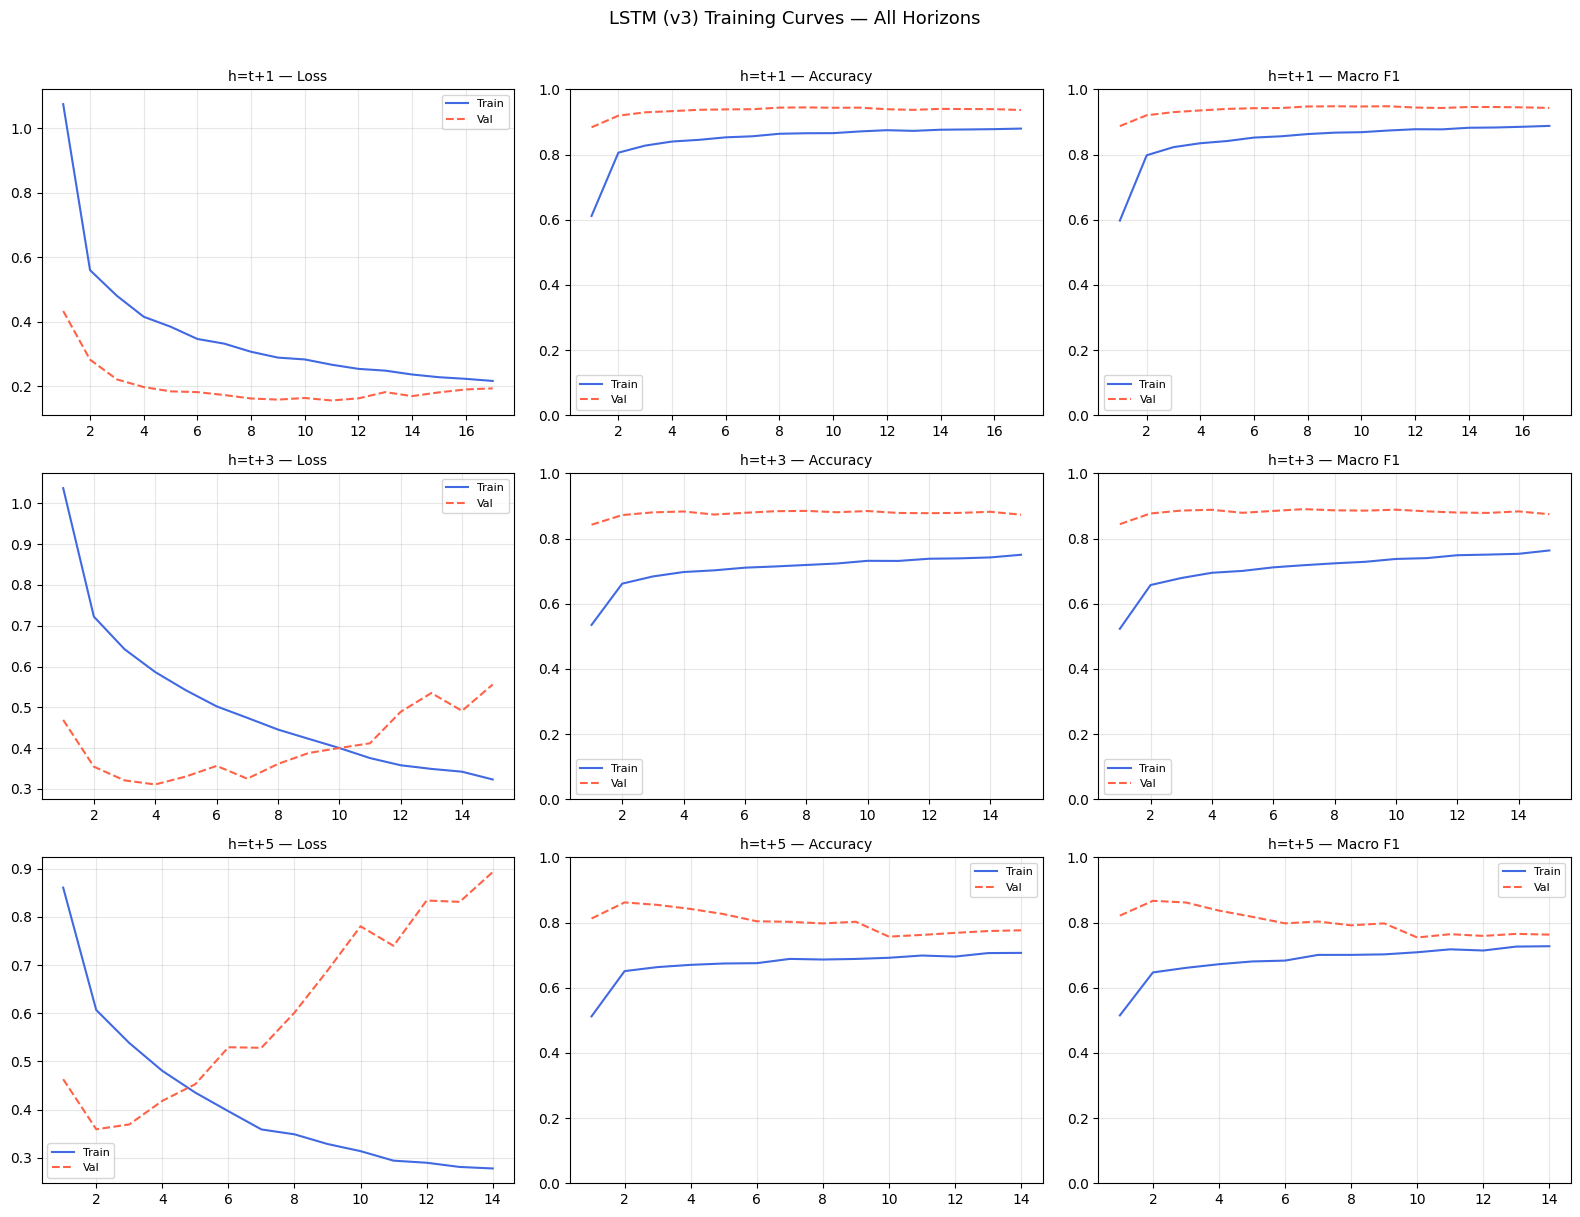

In [95]:
# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(len(CFG['horizons']), 3,
                          figsize=(16, 4 * len(CFG['horizons'])))

for row, h in enumerate(CFG['horizons']):
    hist = histories[h]
    ep   = range(1, len(hist['train_loss']) + 1)
    for col, (tr_k, va_k, title) in enumerate([
        ('train_loss', 'val_loss', 'Loss'),
        ('train_acc',  'val_acc',  'Accuracy'),
        ('train_f1',   'val_f1',   'Macro F1'),
    ]):
        ax = axes[row][col]
        ax.plot(ep, hist[tr_k], label='Train', color='royalblue', lw=1.5)
        ax.plot(ep, hist[va_k], label='Val',   color='tomato', ls='--', lw=1.5)
        ax.set_title(f'h=t+{h} — {title}', fontsize=10)
        ax.legend(fontsize=8)
        if 'loss' not in tr_k:
            ax.set_ylim(0, 1)
        ax.grid(alpha=0.3)

plt.suptitle('LSTM (v3) Training Curves — All Horizons', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('artifacts/lstm_v3_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Evaluation

In [96]:
def evaluate(model, horizon):
    test_loader = make_loader(datasets[horizon]['X_test'],
                              datasets[horizon]['y_test'])
    model.eval()
    all_preds, all_labels = [], []
    t0 = time.time()
    with torch.no_grad():
        for xb, yb in test_loader:
            logits = model(xb.to(DEVICE))
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(yb.numpy())
    lat = (time.time() - t0) / len(all_preds) * 1000
    p, l = np.array(all_preds), np.array(all_labels)
    return dict(
        preds       = p,
        labels      = l,
        acc         = accuracy_score(l, p),
        macro_f1    = f1_score(l, p, average='macro',    zero_division=0),
        weighted_f1 = f1_score(l, p, average='weighted', zero_division=0),
        report      = classification_report(l, p,
                          target_names=label_encoder.classes_, zero_division=0),
        latency_ms  = lat,
    )


eval_results = {}
for h in CFG['horizons']:
    r = evaluate(trained[h], h)
    eval_results[h] = r
    print(f'\n{"="*60}')
    print(f'  LSTM (v3) | h=t+{h} (~{h*2}s ahead)')
    print(f'  Accuracy   : {r["acc"]:.4f}')
    print(f'  Macro F1   : {r["macro_f1"]:.4f}')
    print(f'  Weighted F1: {r["weighted_f1"]:.4f}')
    print(f'  Latency    : {r["latency_ms"]:.4f} ms/sample')
    print(f'{"="*60}')
    print(r['report'])


  LSTM (v3) | h=t+1 (~2s ahead)
  Accuracy   : 0.9365
  Macro F1   : 0.9288
  Weighted F1: 0.9366
  Latency    : 0.0247 ms/sample
                    precision    recall  f1-score   support

         CALL_DROP       0.93      0.93      0.93       780
CAPACITY_EXHAUSTED       0.86      0.94      0.90       448
      HIGH_LATENCY       0.97      0.98      0.98      3508
    LOW_THROUGHPUT       0.89      0.94      0.92      1400
            NORMAL       0.91      0.90      0.90      3836
POOR_VOICE_QUALITY       0.96      0.93      0.95      3988

          accuracy                           0.94     13960
         macro avg       0.92      0.94      0.93     13960
      weighted avg       0.94      0.94      0.94     13960


  LSTM (v3) | h=t+3 (~6s ahead)
  Accuracy   : 0.8681
  Macro F1   : 0.8525
  Weighted F1: 0.8686
  Latency    : 0.0239 ms/sample
                    precision    recall  f1-score   support

         CALL_DROP       0.92      0.86      0.89       780
CAPACITY_EXHAU

In [97]:
# ── Results comparison: v3 vs v2 ──────────────────────────────────────────────
V2_RESULTS = {
    1: dict(acc=0.9165, macro_f1=0.8992, weighted_f1=0.9159),
    3: dict(acc=0.8073, macro_f1=0.7717, weighted_f1=0.8234),
    5: dict(acc=0.6401, macro_f1=0.6105, weighted_f1=0.6373),
}

rows = []
for h in CFG['horizons']:
    r   = eval_results[h]
    prv = V2_RESULTS[h]
    rows.append(dict(
        Horizon    = f't+{h} (~{h*2}s)',
        Acc_v2     = prv['acc'],
        Acc_v3     = round(r['acc'],      4),
        Acc_Delta  = round(r['acc']      - prv['acc'],      4),
        F1_v2      = prv['macro_f1'],
        F1_v3      = round(r['macro_f1'], 4),
        F1_Delta   = round(r['macro_f1'] - prv['macro_f1'], 4),
    ))

summary = pd.DataFrame(rows)
print('\n=== v2 vs v3 Comparison ===')
print(summary.to_string(index=False))
summary.to_csv('artifacts/lstm_v3_results.csv', index=False)


=== v2 vs v3 Comparison ===
   Horizon  Acc_v2  Acc_v3  Acc_Delta  F1_v2  F1_v3  F1_Delta
 t+1 (~2s)  0.9165  0.9365     0.0200 0.8992 0.9288    0.0296
 t+3 (~6s)  0.8073  0.8681     0.0608 0.7717 0.8525    0.0808
t+5 (~10s)  0.6401  0.8560     0.2159 0.6105 0.8326    0.2221


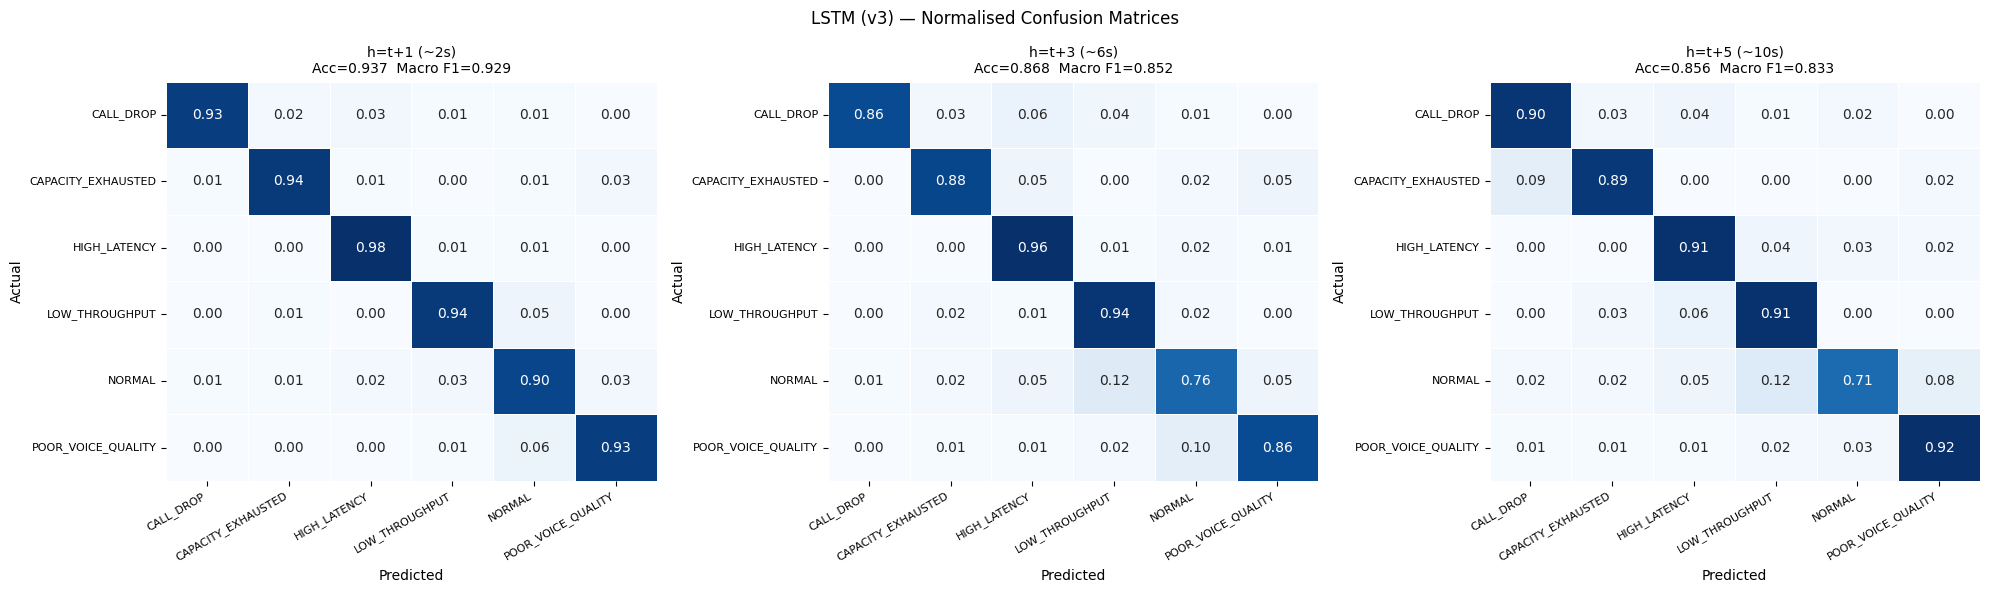

In [98]:
# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, h in zip(axes, CFG['horizons']):
    r = eval_results[h]
    cm = confusion_matrix(r['labels'], r['preds'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(np.round(cm_norm, 2), ax=ax, annot=True, fmt='.2f',
                cmap='Blues', linewidths=0.4, cbar=False,
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    ax.set_title(f'h=t+{h} (~{h*2}s)\nAcc={r["acc"]:.3f}  Macro F1={r["macro_f1"]:.3f}',
                 fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_xticklabels(label_encoder.classes_, rotation=30, ha='right', fontsize=8)
    ax.set_yticklabels(label_encoder.classes_, rotation=0, fontsize=8)

plt.suptitle('LSTM (v3) — Normalised Confusion Matrices', fontsize=12)
plt.tight_layout()
plt.savefig('artifacts/lstm_v3_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

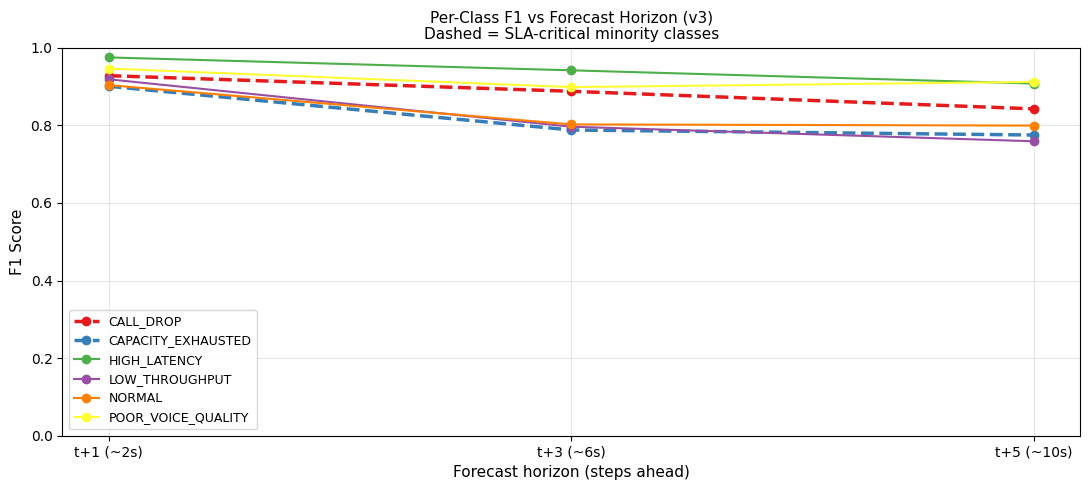

In [99]:
# ── Per-class F1 vs horizon ───────────────────────────────────────────────────
per_class_f1 = {}
for cls_idx, cls_name in enumerate(label_encoder.classes_):
    f1s = []
    for h in CFG['horizons']:
        r  = eval_results[h]
        pc = f1_score(r['labels'], r['preds'], average=None,
                      zero_division=0, labels=np.arange(NUM_CLASSES))
        f1s.append(pc[cls_idx])
    per_class_f1[cls_name] = f1s

fig, ax = plt.subplots(figsize=(11, 5))
colors = plt.cm.Set1.colors
for i, (cls, f1s) in enumerate(per_class_f1.items()):
    is_critical = cls in CFG['minority_boost_classes']
    ax.plot(CFG['horizons'], f1s, marker='o', label=cls,
            color=colors[i % len(colors)],
            ls='--' if is_critical else '-',
            lw=2.5  if is_critical else 1.5)

ax.set_xlabel('Forecast horizon (steps ahead)', fontsize=11)
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_xticks(CFG['horizons'])
ax.set_xticklabels([f't+{h} (~{h*2}s)' for h in CFG['horizons']])
ax.set_ylim(0, 1)
ax.set_title('Per-Class F1 vs Forecast Horizon (v3)\nDashed = SLA-critical minority classes',
             fontsize=11)
ax.legend(fontsize=9, loc='lower left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/lstm_v3_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

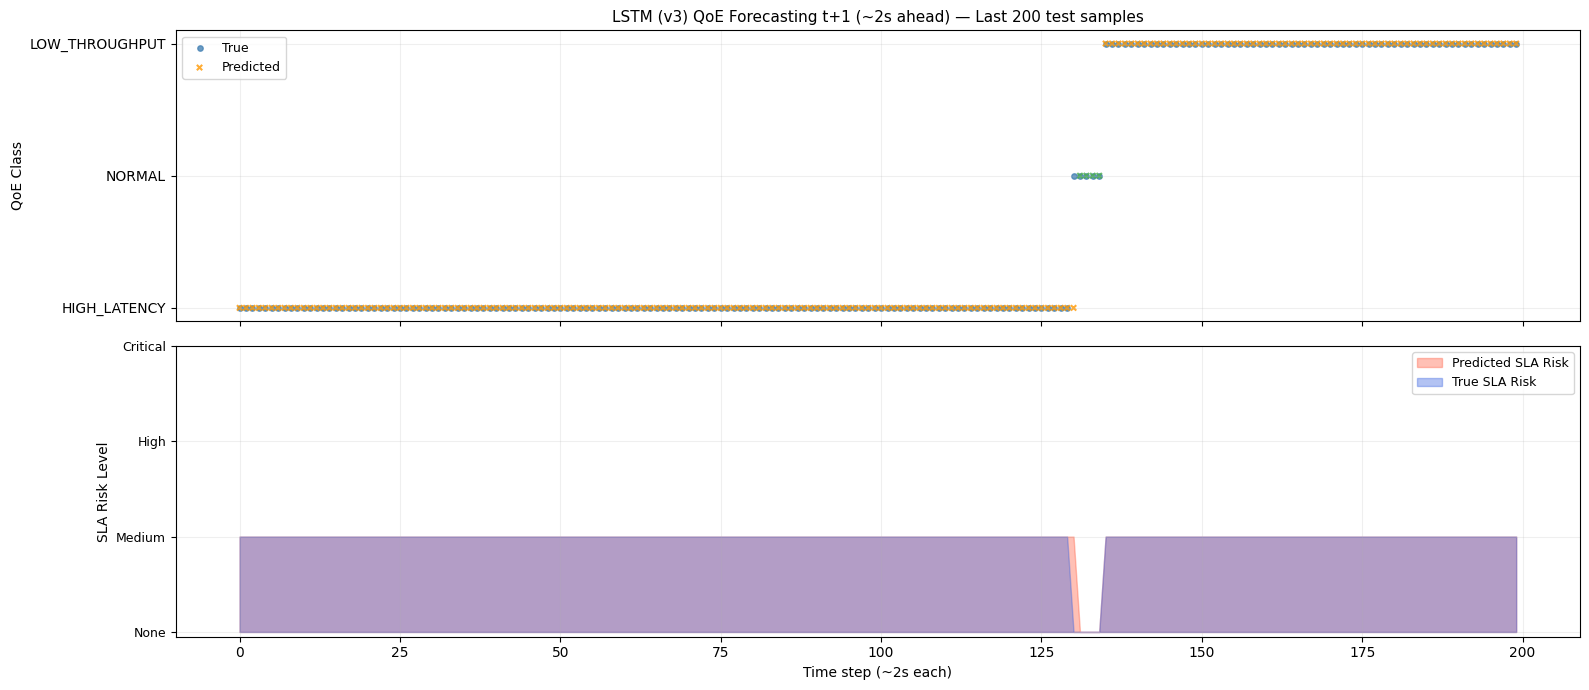

In [100]:
# ── SLA Risk Timeline ─────────────────────────────────────────────────────────
RISK_MAP = {
    'NORMAL':             (0, '#4CAF50'),
    'LOW_THROUGHPUT':     (1, '#FF9800'),
    'HIGH_LATENCY':       (1, '#FF9800'),
    'POOR_VOICE_QUALITY': (2, '#F44336'),
    'CAPACITY_EXHAUSTED': (2, '#F44336'),
    'CALL_DROP':          (3, '#B71C1C'),
}
RISK_LABELS = ['None', 'Medium', 'High', 'Critical']

r      = eval_results[1]
n_show = 200
pred_names = label_encoder.inverse_transform(r['preds'][-n_show:])
true_names = label_encoder.inverse_transform(r['labels'][-n_show:])
risk_pred  = [RISK_MAP.get(l, (0,'gray'))[0] for l in pred_names]
risk_true  = [RISK_MAP.get(l, (0,'gray'))[0] for l in true_names]
colors_p   = [RISK_MAP.get(l, (0,'gray'))[1] for l in pred_names]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
ax1.scatter(range(n_show), true_names,  s=15, color='steelblue', alpha=0.8, label='True')
ax1.scatter(range(n_show), pred_names,  s=15, c=colors_p, alpha=0.8, marker='x', label='Predicted')
ax1.set_ylabel('QoE Class'); ax1.legend(fontsize=9); ax1.grid(alpha=0.2)
ax1.set_title(f'LSTM (v3) QoE Forecasting t+1 (~2s ahead) — Last {n_show} test samples',
              fontsize=11)

ax2.fill_between(range(n_show), risk_pred, alpha=0.4, color='tomato',    label='Predicted SLA Risk')
ax2.fill_between(range(n_show), risk_true, alpha=0.4, color='royalblue', label='True SLA Risk')
ax2.set_yticks([0,1,2,3]); ax2.set_yticklabels(RISK_LABELS, fontsize=9)
ax2.set_ylabel('SLA Risk Level'); ax2.set_xlabel('Time step (~2s each)')
ax2.legend(fontsize=9); ax2.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('artifacts/lstm_v3_sla_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Business Interpretation

| Predicted Class | SLA Risk | Action | Lead Time |
|---|---|---|---|
| `NORMAL` | None | No action | — |
| `HIGH_LATENCY` | Medium | Reroute to lower-latency path | t+1 (~2s) |
| `LOW_THROUGHPUT` | Medium | Increase bandwidth allocation | t+3 (~6s) |
| `POOR_VOICE_QUALITY` | High | Elevate to priority QoS queue | t+1 (~2s) |
| `CAPACITY_EXHAUSTED` | High | Trigger load balancing | t+3 (~6s) |
| `CALL_DROP` | **Critical** | Immediate failover + alert | t+1 (~2s) |

In [101]:
# ── Final Summary ─────────────────────────────────────────────────────────────
print('=' * 65)
print('  QoS SENTRY — LSTM FORECASTING (v3) — FINAL RESULTS')
print('=' * 65)
print(summary.to_string(index=False))
print()
print('v3 Fixes applied (on top of v2):')
print('  Fix A — Per-horizon CFG          → each horizon gets optimal params')
print('  Fix B — Per-horizon minority_boost → no over-firing at t+3/t+5')
print('  Fix C — Larger model for t+5     → hidden=128, layers=3 (was underfitting)')
print('  Fix D — clip_grad 1.0→0.5        → stable gradients at t+5')
print('  Fix E — Focal Loss               → fixes precision collapse on minority classes')
print('  Fix F — Per-horizon patience     → t+3 stops earlier, t+5 later')
print('  Fix G — ReduceLROnPlateau        → LR adapts to val F1 (replaces cosine)')
print('  Fix H — Per-horizon oversample   → reduced at t+3/t+5 (less distortion)')
print()
print('Critical class F1 (CALL_DROP, CAPACITY_EXHAUSTED):')
for cls in ['CALL_DROP', 'CAPACITY_EXHAUSTED']:
    if cls in label_encoder.classes_:
        print(f'  {cls}:')
        for h in CFG['horizons']:
            f1 = per_class_f1[cls][CFG['horizons'].index(h)]
            print(f'    t+{h} (~{h*2}s): F1 = {f1:.3f}')
print()
print('Artifacts saved:')
for f in sorted(os.listdir('artifacts')):
    print(f'  {f}')
print('=' * 65)

  QoS SENTRY — LSTM FORECASTING (v3) — FINAL RESULTS
   Horizon  Acc_v2  Acc_v3  Acc_Delta  F1_v2  F1_v3  F1_Delta
 t+1 (~2s)  0.9165  0.9365     0.0200 0.8992 0.9288    0.0296
 t+3 (~6s)  0.8073  0.8681     0.0608 0.7717 0.8525    0.0808
t+5 (~10s)  0.6401  0.8560     0.2159 0.6105 0.8326    0.2221

v3 Fixes applied (on top of v2):
  Fix A — Per-horizon CFG          → each horizon gets optimal params
  Fix B — Per-horizon minority_boost → no over-firing at t+3/t+5
  Fix C — Larger model for t+5     → hidden=128, layers=3 (was underfitting)
  Fix D — clip_grad 1.0→0.5        → stable gradients at t+5
  Fix E — Focal Loss               → fixes precision collapse on minority classes
  Fix F — Per-horizon patience     → t+3 stops earlier, t+5 later
  Fix G — ReduceLROnPlateau        → LR adapts to val F1 (replaces cosine)
  Fix H — Per-horizon oversample   → reduced at t+3/t+5 (less distortion)

Critical class F1 (CALL_DROP, CAPACITY_EXHAUSTED):
  CALL_DROP:
    t+1 (~2s): F1 = 0.928
    